# Sentiment Analysis with NLTK

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CDAC-lab/BUS3005-Resources/blob/main/NLP_1_Sentiment_Analysis.ipynb)

**Sentiment analysis** is the task of automatically deciding whether a piece of text is **positive**, **negative**, or **neutral** in tone. It's one of the most common and useful jobs in Natural Language Processing (NLP), used to:

 * track how customers feel about a product from their reviews,
 * monitor public opinion on social media, and
 * flag unhappy support tickets so a human can respond quickly.

In this notebook we'll use a beginner-friendly tool called **VADER** (from the [NLTK](https://www.nltk.org/) library) to score the sentiment of some example reviews, and then **visualise** the results so the patterns are easy to see.

There is no machine-learning training involved here &mdash; VADER is a *lexicon* (a big dictionary of words with sentiment scores), which makes it fast, transparent, and perfect for learning.

Click the **Play** icon beside each cell to run it, working through the notebook from top to bottom.


First we install and import the libraries. This takes only a few seconds in Google Colab.

In [7]:
#@title Install and import software libraries
!pip install nltk wordcloud --quiet

import pandas as pd
import matplotlib.pyplot as plt

import nltk
# VADER's sentiment dictionary, plus a tokenizer and a stopword list we'll use later
nltk.download("vader_lexicon", quiet=True)
nltk.download("stopwords", quiet=True)

from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from nltk.corpus import stopwords

print("Libraries ready.")

Libraries ready.


## Meet VADER

**VADER** stands for *Valence Aware Dictionary and sEntiment Reasoner*. Give it a sentence, and it returns four numbers:

 * **pos**, **neu**, **neg** &mdash; the proportion of the text that is positive, neutral, and negative (these add up to 1), and
 * **compound** &mdash; a single overall score from **&minus;1** (most negative) to **+1** (most positive).

The **compound** score is the one we'll mostly use. Let's try it on a few sentences.


In [8]:
sia = SentimentIntensityAnalyzer()

examples = [
    "I absolutely love this, it works perfectly!",
    "This is the worst thing I have ever bought.",
    "The package arrived on Tuesday.",
]

for sentence in examples:
    scores = sia.polarity_scores(sentence)
    print(sentence)
    print("   ", scores, "\n")

I absolutely love this, it works perfectly!
    {'neg': 0.0, 'neu': 0.308, 'pos': 0.692, 'compound': 0.8746} 

This is the worst thing I have ever bought.
    {'neg': 0.369, 'neu': 0.631, 'pos': 0.0, 'compound': -0.6249} 

The package arrived on Tuesday.
    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} 



Notice how:

 * the happy sentence has a **compound** close to **+1**,
 * the angry one is close to **&minus;1**, and
 * the factual one sits near **0** (neutral).

A common convention is to turn the compound score into a **label** using these cut-offs:

 * compound **&ge; 0.05** &rarr; **Positive**
 * compound **&le; &minus;0.05** &rarr; **Negative**
 * otherwise &rarr; **Neutral**

VADER also understands things simple word-counting misses, like capital letters ("GREAT" is stronger than "great"), exclamation marks, and words like "not" that flip meaning.


## A small dataset of customer reviews

Let's analyse a batch of reviews at once. We'll put them in a table (a pandas `DataFrame`), score each one with VADER, and add a sentiment label.


In [9]:
reviews = [
    "Absolutely love this phone, the battery lasts all day!",
    "Worst purchase ever. It broke after two days.",
    "The food was okay, nothing special but not bad either.",
    "Fantastic service and super friendly staff, highly recommend!",
    "I'm really disappointed, the product did not match the description.",
    "It works fine. Does the job.",
    "This is the best book I have read in years, truly inspiring!",
    "Terrible experience, I will never come back again.",
    "Shipping was fast but the item was slightly damaged.",
    "Great value for money, I am very happy with it.",
    "The app keeps crashing and support has been useless.",
    "Comfortable, stylish, and surprisingly affordable.",
    "Not what I expected, quite underwhelming honestly.",
    "The hotel room was clean and the view was breathtaking!",
    "Rude staff and long waiting times ruined the visit.",
]

def label(compound):
    if compound >= 0.05:
        return "Positive"
    if compound <= -0.05:
        return "Negative"
    return "Neutral"

rows = []
for r in reviews:
    compound = sia.polarity_scores(r)["compound"]
    rows.append({"review": r, "compound": compound, "sentiment": label(compound)})

df = pd.DataFrame(rows)
df

,review,compound,sentiment
0,"Absolutely love this phone, the battery lasts ...",0.6989,Positive
1,Worst purchase ever. It broke after two days.,-0.7845,Negative
2,"The food was okay, nothing special but not bad...",0.5568,Positive
3,"Fantastic service and super friendly staff, hi...",0.9298,Positive
4,"I'm really disappointed, the product did not m...",-0.5256,Negative
5,It works fine. Does the job.,0.2023,Positive
6,"This is the best book I have read in years, tr...",0.8805,Positive
7,"Terrible experience, I will never come back ag...",-0.4767,Negative
8,Shipping was fast but the item was slightly da...,-0.5284,Negative
9,"Great value for money, I am very happy with it.",0.8883,Positive


## Visualising the results

A table is fine, but a picture makes the overall mood obvious at a glance. Let's make two charts:

1. **How many reviews** fall into each sentiment category, and
2. **The score of every individual review**, sorted from most negative to most positive.


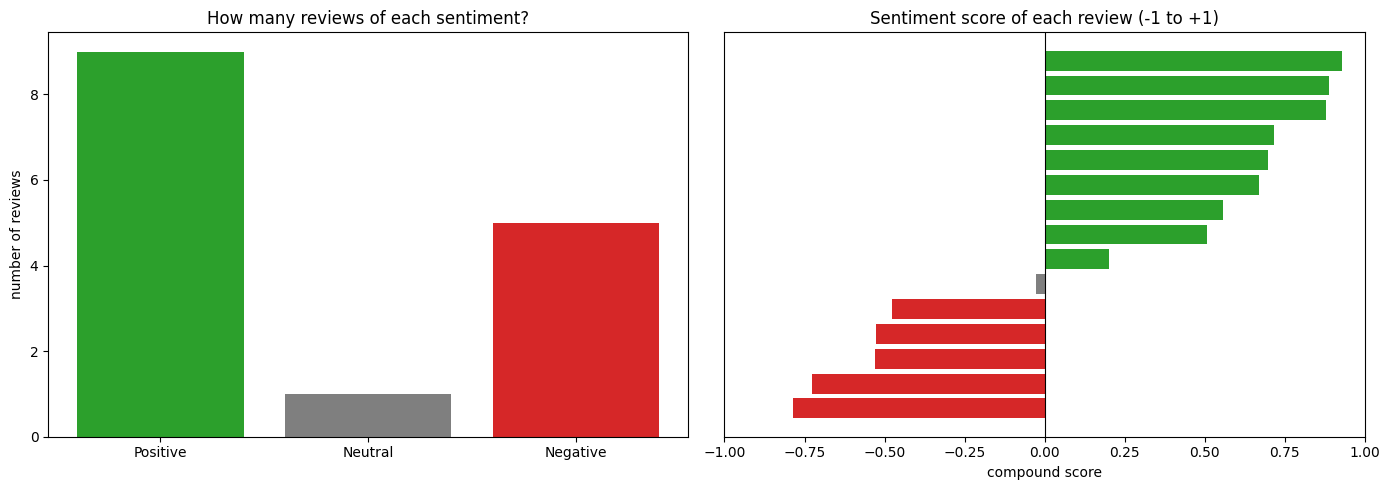

In [10]:
colors = {"Positive": "#2ca02c", "Neutral": "#7f7f7f", "Negative": "#d62728"}

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: counts per sentiment
counts = df["sentiment"].value_counts().reindex(["Positive", "Neutral", "Negative"]).fillna(0)
ax[0].bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
ax[0].set_title("How many reviews of each sentiment?")
ax[0].set_ylabel("number of reviews")

# Chart 2: score of each review
d = df.sort_values("compound")
ax[1].barh(range(len(d)), d["compound"], color=[colors[s] for s in d["sentiment"]])
ax[1].axvline(0, color="black", linewidth=0.8)
ax[1].set_yticks([])
ax[1].set_xlim(-1, 1)
ax[1].set_title("Sentiment score of each review (-1 to +1)")
ax[1].set_xlabel("compound score")

plt.tight_layout()
plt.show()

The left chart summarises the mood of the whole batch. The right chart shows the *spread*: bars stretching left are unhappy reviews, bars stretching right are happy ones, and the length tells you how strong the feeling is.

This kind of view scales up: swap in 10,000 real reviews and the same two charts instantly tell you whether customers are mostly satisfied.


### Which words drive positive vs. negative reviews?

A **word cloud** shows the most frequent words, with bigger words appearing more often. Let's build one cloud from the positive reviews and one from the negative reviews to see what language each group uses. (We remove common "stopwords" like *the* and *and*, which carry no sentiment.)


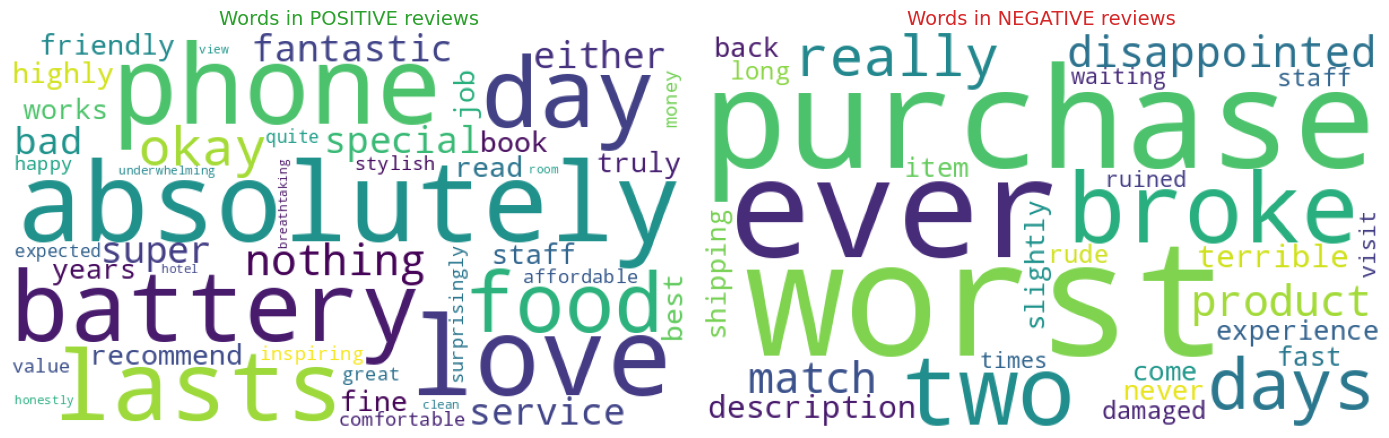

In [11]:
stop = set(stopwords.words("english"))

def make_cloud(texts):
    words = " ".join(texts).lower()
    return WordCloud(width=600, height=350, background_color="white",
                     stopwords=stop, colormap="viridis").generate(words)

pos_text = df[df["sentiment"] == "Positive"]["review"]
neg_text = df[df["sentiment"] == "Negative"]["review"]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(make_cloud(pos_text)); ax[0].axis("off")
ax[0].set_title("Words in POSITIVE reviews", color="#2ca02c", fontsize=14)
ax[1].imshow(make_cloud(neg_text)); ax[1].axis("off")
ax[1].set_title("Words in NEGATIVE reviews", color="#d62728", fontsize=14)
plt.tight_layout()
plt.show()

The positive cloud fills with words like *love*, *great*, and *recommend*, while the negative cloud shows *worst*, *terrible*, and *disappointed*. Word clouds are a quick, intuitive way to explore what a group of texts is really talking about.


## Try it yourself

Change the text below to anything you like &mdash; a tweet, a review you wrote, a message &mdash; and run the cell to see VADER's verdict.


In [12]:
my_text = "The plot was predictable, but honestly I still enjoyed every minute!"  #@param {type:"string"}

scores = sia.polarity_scores(my_text)
print("Text:    ", my_text)
print("Scores:  ", scores)
print("Verdict: ", label(scores["compound"]))

Text:     The plot was predictable, but honestly I still enjoyed every minute!
Scores:   {'neg': 0.0, 'neu': 0.478, 'pos': 0.522, 'compound': 0.8671}
Verdict:  Positive


## Where VADER struggles

VADER is quick and needs no training, but it has real limits worth knowing:

 * **Sarcasm and irony** &mdash; *"Oh great, another delay."* looks positive to VADER because of the word *great*.
 * **Context and domain** &mdash; *"unpredictable"* is bad for a car but good for a thriller novel. VADER uses one fixed dictionary regardless of topic.
 * **Comparisons and negation chains** &mdash; long, complex sentences can confuse it.
 * **Languages other than English** &mdash; the built-in lexicon is English-only.

For harder problems, people train machine-learning or deep-learning models (often using labelled data), which can learn context &mdash; at the cost of needing training data and being less transparent than a simple dictionary.


# Discussion points

 * Look back at the "Neutral" reviews. Do you agree with VADER, or would a human label them differently?
 * Can you write a sentence that is genuinely positive but that VADER scores as negative (or vice versa)?
 * If you ran this on 50,000 reviews, what business decisions could the two charts support?
 * VADER is transparent (you can inspect exactly why it scored something). When is transparency more important than raw accuracy?


# Further reading

 * [**NLTK Sentiment Analysis**](https://www.nltk.org/howto/sentiment.html) &mdash; official documentation.
 * Hutto, C.J. & Gilbert, E. (2014). *VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text.* ICWSM.
 * [**TextBlob**](https://textblob.readthedocs.io/) &mdash; another beginner-friendly sentiment tool worth comparing against VADER.

---
*This notebook was inspired in part by community sentiment-analysis tutorials such as [RichardRivaldo/Sentiment-Analysis](https://github.com/RichardRivaldo/Sentiment-Analysis), simplified here for teaching with NLTK's VADER.*
